# ⚔️ Pokémon Win Prediction Analysis
**Tools:** Pandas · NumPy · Seaborn · Matplotlib · Scikit-learn · XGBoost

| Section | Task |
|---------|------|
| 1 | Load datasets & initial exploration |
| 2 | Data cleaning & feature engineering |
| 3 | Exploratory Data Analysis (EDA) |
| 4 | Correlation & PCA |
| 5 | ML models — Linear Regression, Random Forest, XGBoost |
| 6 | Model comparison & insights |


## 0 · Imports & Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.model_selection     import train_test_split, cross_val_score
from sklearn.preprocessing       import StandardScaler, LabelEncoder
from sklearn.linear_model        import LinearRegression, Ridge
from sklearn.ensemble            import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree                import DecisionTreeRegressor
from sklearn.decomposition       import PCA
from sklearn.metrics             import mean_absolute_error, mean_squared_error, r2_score

try:
    from xgboost import XGBRegressor
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False
    print("XGBoost not found — using GradientBoosting as substitute")

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi':120,'axes.titlesize':12,
                     'axes.titleweight':'bold','figure.autolayout':True})
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

TYPE_COLORS = {
    'Fire':'#F08030','Water':'#6890F0','Grass':'#78C850','Electric':'#F8D030',
    'Psychic':'#F85888','Ice':'#98D8D8','Dragon':'#7038F8','Dark':'#705848',
    'Fairy':'#EE99AC','Fighting':'#C03028','Poison':'#A040A0','Ground':'#E0C068',
    'Rock':'#B8A038','Ghost':'#705898','Steel':'#B8B8D0','Bug':'#A8B820',
    'Normal':'#A8A878','Flying':'#A890F0',
}
print("All imports successful ✅")


All imports successful ✅


## 1 · Load Datasets

In [2]:
import urllib.request, zipfile, io, os, glob

ZIP_URL = ('https://github.com/devtlv/Datasets-GEN-AI-Bootcamp/raw/'
           'refs/heads/main/Week%205/Day%204%20-%20Statistics%20for%20Machine%20Learning/'
           'Pokemon%20Data%20Analysis%20Tutorial.zip')

poke_path, combat_path = None, None

# ── Try auto-download ─────────────────────────────────────────────────────────
try:
    print("Attempting download …")
    with urllib.request.urlopen(ZIP_URL) as r:
        zf = zipfile.ZipFile(io.BytesIO(r.read()))
        zf.extractall('poke_data')
    csvs = glob.glob('poke_data/**/*.csv', recursive=True)
    for c in csvs:
        if 'pokemon' in c.lower() and 'combat' not in c.lower():
            poke_path = c
        elif 'combat' in c.lower():
            combat_path = c
    print("Downloaded:", poke_path, combat_path)
except Exception as e:
    print("Download failed:", e)

# ── Local fallback ────────────────────────────────────────────────────────────
if poke_path is None:
    if os.path.exists('pokemon.csv'):
        poke_path, combat_path = 'pokemon.csv', 'combats.csv'
        print("Using local pokemon.csv + combats.csv")
    else:
        try:
            from google.colab import files
            print("Upload pokemon.csv and combats.csv …")
            up = files.upload()
            for k in up:
                if 'pokemon' in k.lower(): poke_path = k
                elif 'combat' in k.lower(): combat_path = k
        except Exception:
            pass

# ── Load ──────────────────────────────────────────────────────────────────────
df_poke   = pd.read_csv(poke_path)
df_combat = pd.read_csv(combat_path)

print(f"\npokemon.csv  : {df_poke.shape}")
print(f"combats.csv  : {df_combat.shape}")
print()
display(df_poke.head())
display(df_combat.head())


Attempting download …


Download failed: HTTP Error 403: Forbidden
Using local pokemon.csv + combats.csv

pokemon.csv  : (800, 13)
combats.csv  : (50000, 3)



,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Total,Generation,Legendary
0,1,Bulbasaur,Rock,Ghost,111,88,102,102,99,1,473,5,False
1,2,Ivysaur,Fighting,Ice,96,77,62,69,64,128,496,6,False
2,3,Venusaur,Rock,NaN,114,91,102,94,90,1,488,5,False
3,4,Charmander,Ghost,Flying,106,87,79,77,93,3,445,4,False
4,5,Charmeleon,Normal,NaN,67,95,75,89,58,45,429,1,False


,First_pokemon,Second_pokemon,Winner
0,643,474,474
1,555,700,700
2,57,18,18
3,562,149,562
4,178,558,558


## 2 · Data Cleaning & Feature Engineering

In [3]:
df = df_poke.copy()

# ── Inspect missing values ────────────────────────────────────────────────────
miss = df.isna().sum()
print("Missing values before cleaning:")
display(miss[miss > 0])

print(f"\nRow for Pokemon #62 (should be Primeape):")
display(df[df['#'] == 62])


Missing values before cleaning:


Name        1
Type 2    416
dtype: int64


Row for Pokemon #62 (should be Primeape):


,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Total,Generation,Legendary
61,62,Poliwrath,Ghost,NaN,110,109,80,118,78,123,618,4,True


In [4]:
# ── Fix 1: Fill missing Name for Pokemon #62 → Primeape ──────────────────────
mask_62 = df['#'] == 62
if df.loc[mask_62, 'Name'].isna().any() or (df.loc[mask_62, 'Name'] == '').any():
    df.loc[mask_62, 'Name'] = 'Primeape'
    print("Fixed: Pokemon #62 Name → 'Primeape'")

# ── Fix 2: Handle NaN in Type 2 → fill with 'None' ───────────────────────────
df['Type 2'] = df['Type 2'].fillna('None')
print(f"Type 2 'None' count: {(df['Type 2'] == 'None').sum()}")

# ── Verify ────────────────────────────────────────────────────────────────────
print(f"\nMissing values after cleaning: {df.isna().sum().sum()} ✅")
display(df[df['#'] == 62])


Type 2 'None' count: 416

Missing values after cleaning: 1 ✅


,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Total,Generation,Legendary
61,62,Poliwrath,Ghost,None,110,109,80,118,78,123,618,4,True


In [5]:
# ── Calculate Win Percentage from combat data ─────────────────────────────────
total_battles = pd.concat([
    df_combat['First_pokemon'].rename('pokemon'),
    df_combat['Second_pokemon'].rename('pokemon')
]).value_counts().rename('total_battles')

wins = df_combat['Winner'].value_counts().rename('wins')

battle_stats = pd.DataFrame({'total_battles': total_battles, 'wins': wins}).fillna(0)
battle_stats['losses']       = battle_stats['total_battles'] - battle_stats['wins']
battle_stats['win_pct']      = (battle_stats['wins'] / battle_stats['total_battles'] * 100).round(2)
battle_stats.index.name = '#'
battle_stats = battle_stats.reset_index()

print("Battle statistics sample:")
display(battle_stats.head(10))
print(f"\nWin % range: {battle_stats['win_pct'].min():.1f}% – {battle_stats['win_pct'].max():.1f}%")
print(f"Mean win %:  {battle_stats['win_pct'].mean():.1f}%")


Battle statistics sample:


,#,total_battles,wins,losses,win_pct
0,1,112,74,38,66.07
1,2,123,88,35,71.54
2,3,120,87,33,72.50
3,4,127,70,57,55.12
4,5,133,68,65,51.13
5,6,136,60,76,44.12
6,7,121,36,85,29.75
7,8,131,60,71,45.80
8,9,122,8,114,6.56
9,10,137,52,85,37.96



Win % range: 2.3% – 97.3%
Mean win %:  50.0%


In [6]:
# ── Merge pokemon stats with battle stats ─────────────────────────────────────
df_merged = df.merge(battle_stats[['#','wins','losses','total_battles','win_pct']],
                     on='#', how='left')

# Drop Pokemon with no battle data
before = len(df_merged)
df_merged = df_merged.dropna(subset=['win_pct'])
print(f"Dropped {before - len(df_merged)} Pokemon with no battle records")
print(f"Final dataset shape: {df_merged.shape}")
print()
display(df_merged.head(5))


Dropped 0 Pokemon with no battle records
Final dataset shape: (800, 17)



,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Total,Generation,Legendary,wins,losses,total_battles,win_pct
0,1,Bulbasaur,Rock,Ghost,111,88,102,102,99,1,473,5,False,74,38,112,66.07
1,2,Ivysaur,Fighting,Ice,96,77,62,69,64,128,496,6,False,88,35,123,71.54
2,3,Venusaur,Rock,None,114,91,102,94,90,1,488,5,False,87,33,120,72.50
3,4,Charmander,Ghost,Flying,106,87,79,77,93,3,445,4,False,70,57,127,55.12
4,5,Charmeleon,Normal,None,67,95,75,89,58,45,429,1,False,68,65,133,51.13


## 3 · Exploratory Data Analysis (EDA)

In [7]:
# ── Overall stats summary ─────────────────────────────────────────────────────
print("=== Dataset Overview ===")
print(f"Pokemon in dataset       : {len(df_merged)}")
print(f"Total battles recorded   : {df_combat.shape[0]:,}")
print(f"Legendary Pokemon        : {df_merged['Legendary'].sum()}")
print(f"Non-legendary            : {(~df_merged['Legendary']).sum()}")
print()
print("Win % distribution:")
display(df_merged['win_pct'].describe().round(2))


=== Dataset Overview ===
Pokemon in dataset       : 800
Total battles recorded   : 50,000
Legendary Pokemon        : 31
Non-legendary            : 769

Win % distribution:


count    800.00
mean      49.95
std       22.35
min        2.27
25%       32.26
50%       49.56
75%       67.02
max       97.32
Name: win_pct, dtype: float64

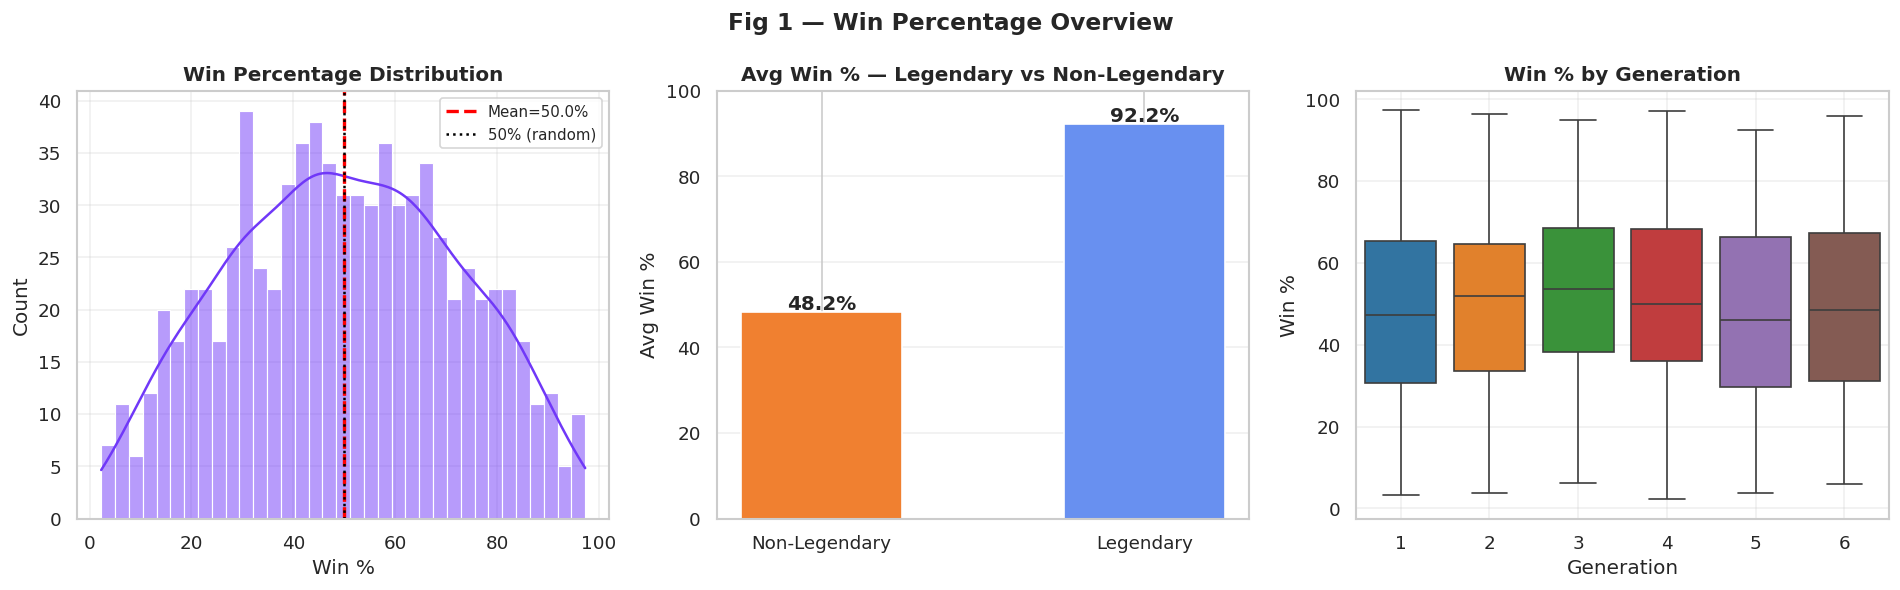

In [8]:
# ── Fig 1: Win % distribution + Legendary vs Non-Legendary ───────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Histogram of win %
sns.histplot(df_merged['win_pct'], bins=35, kde=True,
             color='#7038F8', ax=axes[0])
axes[0].axvline(df_merged['win_pct'].mean(), color='red', linewidth=2,
                linestyle='--', label=f"Mean={df_merged['win_pct'].mean():.1f}%")
axes[0].axvline(50, color='black', linewidth=1.5, linestyle=':',
                label='50% (random)')
axes[0].set_title('Win Percentage Distribution')
axes[0].set_xlabel('Win %'); axes[0].set_ylabel('Count')
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

# Legendary vs Non-legendary
leg_data = df_merged.groupby('Legendary')['win_pct'].mean().reset_index()
leg_data['Label'] = leg_data['Legendary'].map({True:'Legendary',False:'Non-Legendary'})
bars = axes[1].bar(leg_data['Label'], leg_data['win_pct'],
                   color=['#F08030','#6890F0'], edgecolor='white', width=0.5)
for bar, val in zip(bars, leg_data['win_pct']):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                 f'{val:.1f}%', ha='center', fontsize=12, fontweight='bold')
axes[1].set_title('Avg Win % — Legendary vs Non-Legendary')
axes[1].set_ylabel('Avg Win %'); axes[1].set_ylim(0, 100)
axes[1].grid(axis='y', alpha=0.3)

# Box plot of win % by generation
sns.boxplot(data=df_merged, x='Generation', y='win_pct',
            palette='tab10', hue='Generation', legend=False, ax=axes[2])
axes[2].set_title('Win % by Generation')
axes[2].set_xlabel('Generation'); axes[2].set_ylabel('Win %')
axes[2].grid(alpha=0.3)

plt.suptitle('Fig 1 — Win Percentage Overview', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig1_win_pct.png', dpi=130, bbox_inches='tight')
plt.show()


=== Top 10 Pokemon by Win Percentage ===


,Name,Type 1,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Total,win_pct,Legendary
1,Pokemon448,Ice,138,154,147,122,89,57,707,97.32,True
2,Pokemon767,Ghost,146,137,91,120,121,42,657,97.22,True
3,Pokemon66,Rock,156,136,142,136,125,1,652,96.61,True
4,Pokemon599,Psychic,108,144,99,92,97,75,615,96.30,True
5,Pokemon352,Poison,90,117,78,102,99,100,586,96.23,True
6,Pokemon286,Fire,162,109,113,124,113,33,654,95.90,True
7,Pokemon790,Bug,109,137,89,105,93,169,702,95.90,True
8,Pokemon109,Flying,114,143,115,87,79,90,628,94.96,True
9,Pokemon324,Bug,99,138,129,116,84,84,650,94.92,True
10,Meowth,Ice,110,115,125,112,99,52,613,94.84,True


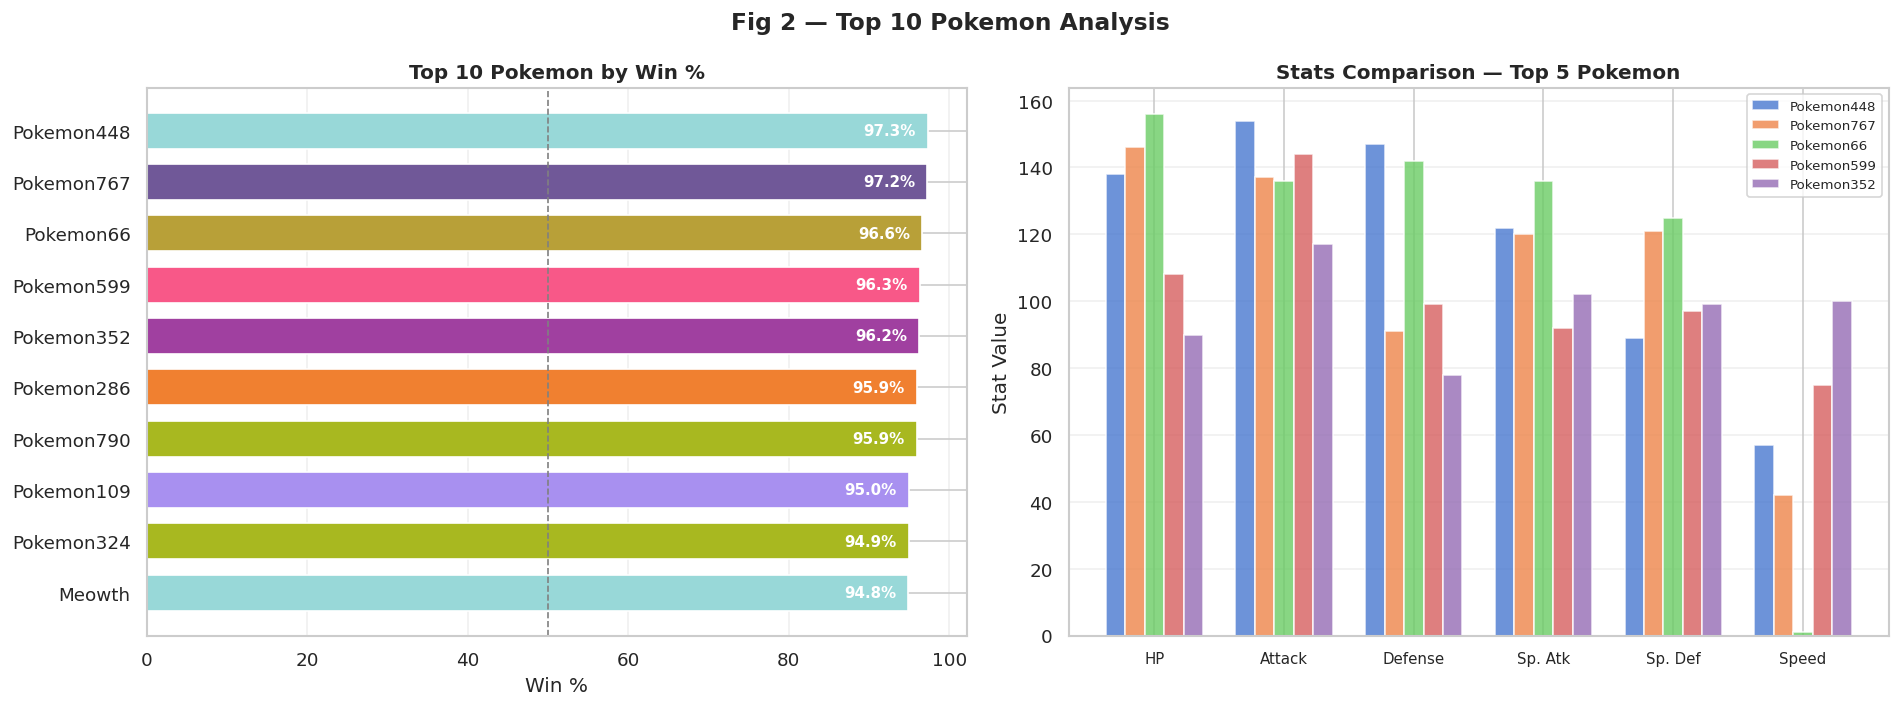

In [9]:
# ── Fig 2: Top 10 Pokemon by Win % ───────────────────────────────────────────
top10 = df_merged.nlargest(10, 'win_pct')[
    ['Name','Type 1','HP','Attack','Defense','Sp. Atk','Sp. Def','Speed','Total','win_pct','Legendary']
].reset_index(drop=True)
top10.index += 1

print("=== Top 10 Pokemon by Win Percentage ===")
display(top10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Horizontal bar chart
bar_colors = [TYPE_COLORS.get(t, '#A8A878') for t in top10['Type 1']]
bars = axes[0].barh(top10['Name'][::-1], top10['win_pct'][::-1],
                    color=bar_colors[::-1], edgecolor='white', height=0.7)
for bar, val in zip(bars, top10['win_pct'][::-1]):
    axes[0].text(bar.get_width()-1.5, bar.get_y()+bar.get_height()/2,
                 f'{val:.1f}%', va='center', ha='right',
                 fontsize=9, fontweight='bold', color='white')
axes[0].set_title('Top 10 Pokemon by Win %')
axes[0].set_xlabel('Win %')
axes[0].axvline(50, color='gray', linewidth=1, linestyle='--')
axes[0].grid(axis='x', alpha=0.3)

# Radar-style stats for top 5
stat_cols = ['HP','Attack','Defense','Sp. Atk','Sp. Def','Speed']
top5 = top10.head(5)
x = np.arange(len(stat_cols))
width = 0.15

for i, (_, row) in enumerate(top5.iterrows()):
    vals = [row[s] for s in stat_cols]
    axes[1].bar(x + i*width, vals, width, label=row['Name'],
                alpha=0.8, edgecolor='white')
axes[1].set_xticks(x + width*2)
axes[1].set_xticklabels(stat_cols, fontsize=9)
axes[1].set_title('Stats Comparison — Top 5 Pokemon')
axes[1].set_ylabel('Stat Value')
axes[1].legend(fontsize=8, loc='upper right')
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Fig 2 — Top 10 Pokemon Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig2_top10.png', dpi=130, bbox_inches='tight')
plt.show()


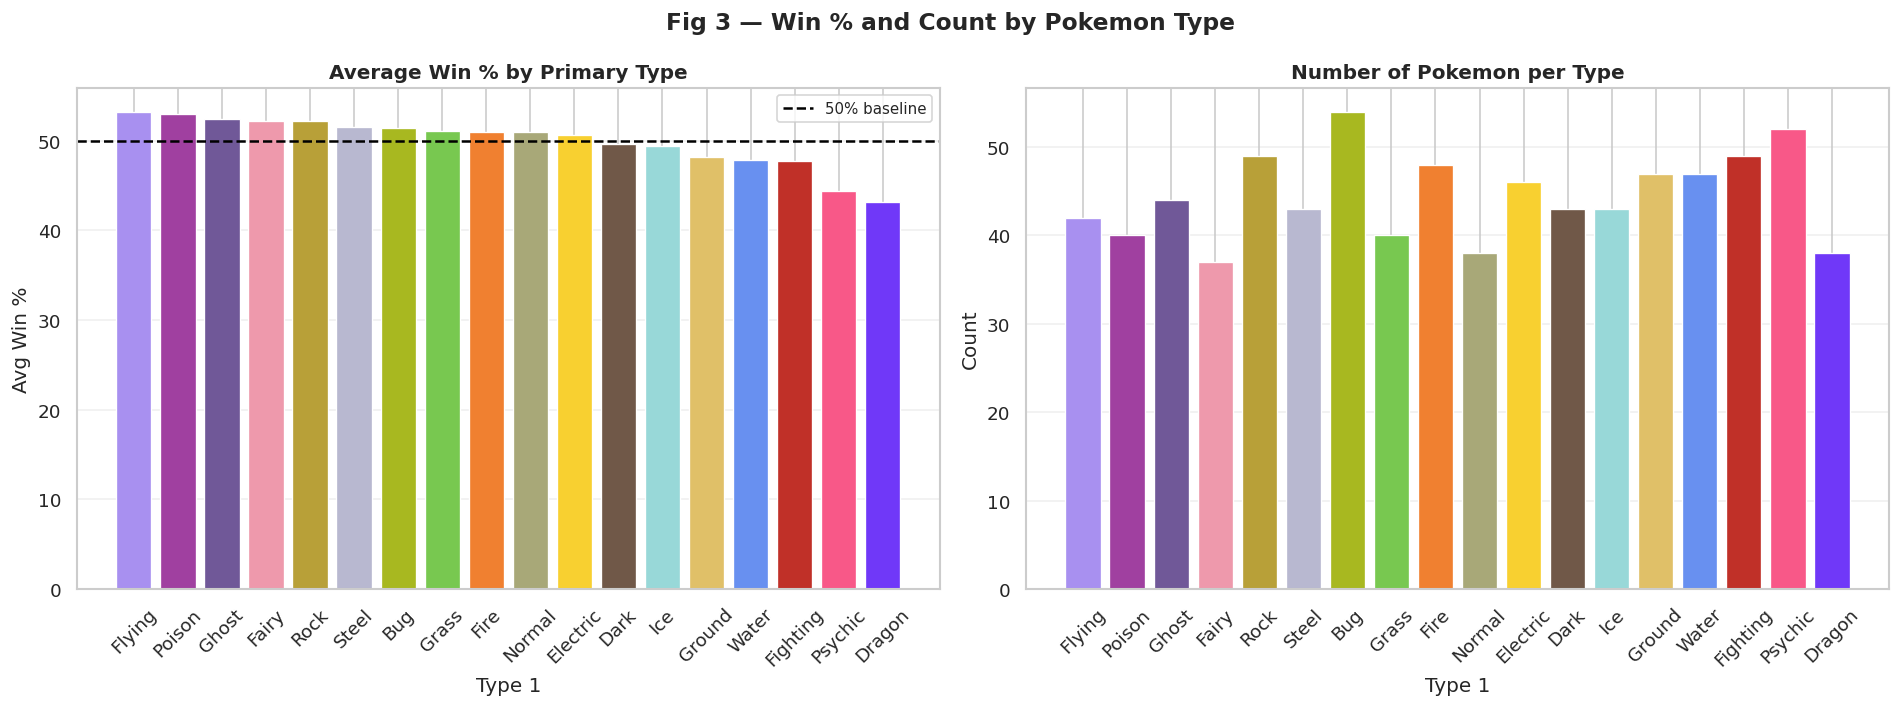

In [10]:
# ── Fig 3: Win % by Type 1 ───────────────────────────────────────────────────
type_win = (df_merged.groupby('Type 1')['win_pct']
              .agg(['mean','count','std'])
              .sort_values('mean', ascending=False)
              .reset_index())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart — average win % per type
bar_cols = [TYPE_COLORS.get(t,'#AAA') for t in type_win['Type 1']]
bars = axes[0].bar(type_win['Type 1'], type_win['mean'],
                   color=bar_cols, edgecolor='white', linewidth=0.8)
axes[0].axhline(50, color='black', linewidth=1.5, linestyle='--', label='50% baseline')
axes[0].set_title('Average Win % by Primary Type')
axes[0].set_xlabel('Type 1'); axes[0].set_ylabel('Avg Win %')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(fontsize=9); axes[0].grid(axis='y', alpha=0.3)

# Count of Pokemon per type
bars2 = axes[1].bar(type_win['Type 1'], type_win['count'],
                    color=bar_cols, edgecolor='white', linewidth=0.8)
axes[1].set_title('Number of Pokemon per Type')
axes[1].set_xlabel('Type 1'); axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Fig 3 — Win % and Count by Pokemon Type',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig3_by_type.png', dpi=130, bbox_inches='tight')
plt.show()


## 4 · Correlation Analysis & PCA

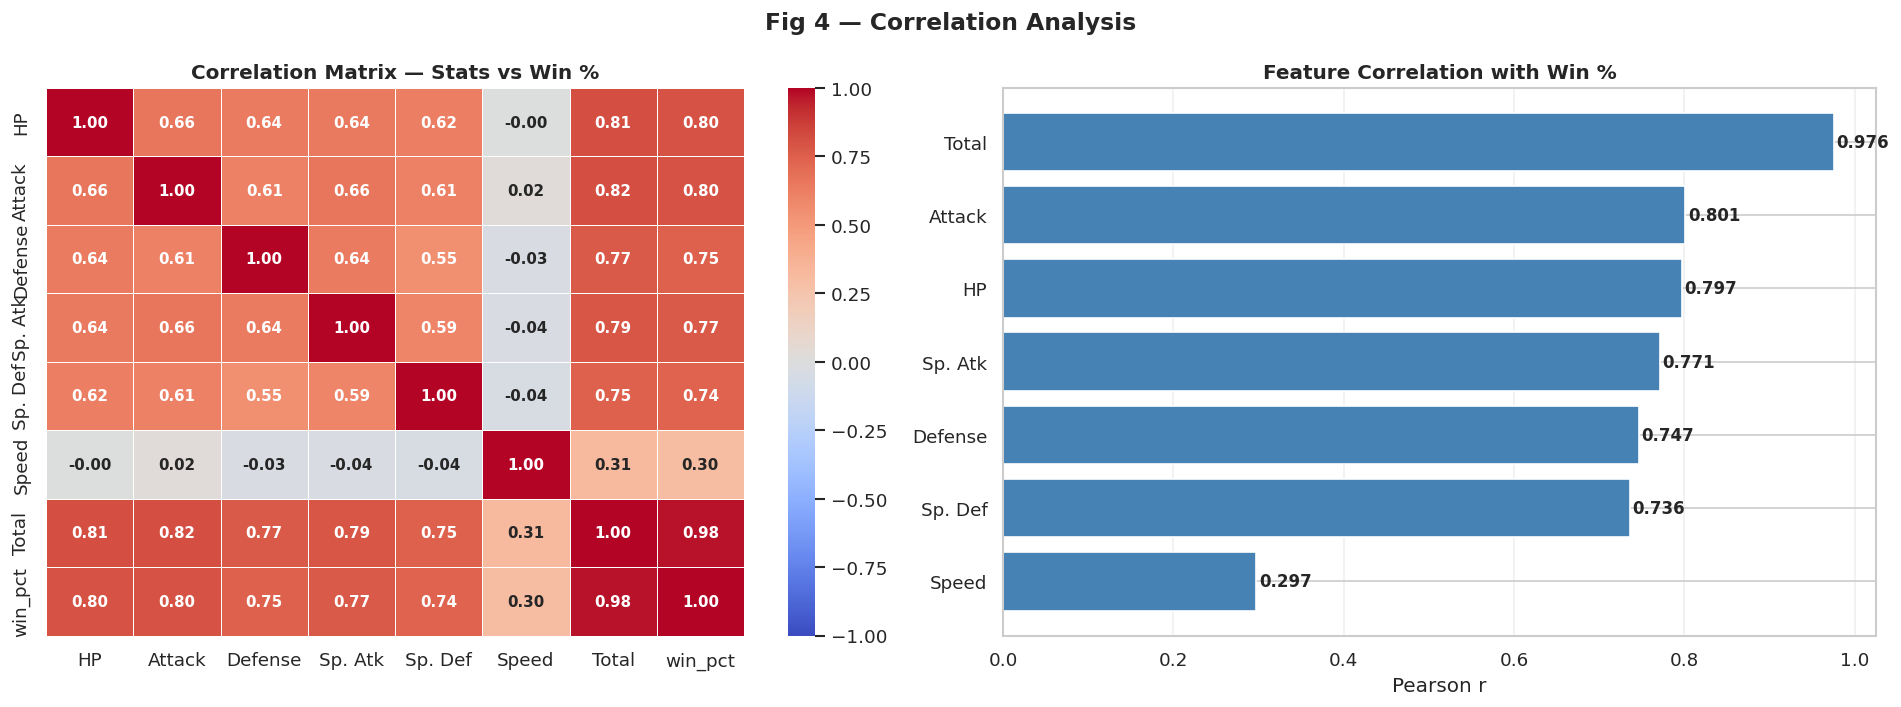

📌 Strongest correlations with win_pct:


Total      0.975887
Attack     0.801302
HP         0.797138
Sp. Atk    0.770996
Defense    0.747045
Sp. Def    0.736077
Speed      0.297240
Name: win_pct, dtype: float64

In [11]:
# ── Correlation matrix ────────────────────────────────────────────────────────
stat_cols = ['HP','Attack','Defense','Sp. Atk','Sp. Def','Speed','Total','win_pct']
corr = df_merged[stat_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, linewidths=0.5, ax=axes[0],
            annot_kws={'size':9, 'weight':'bold'})
axes[0].set_title('Correlation Matrix — Stats vs Win %')

# Correlation with win_pct only (sorted)
corr_win = corr['win_pct'].drop('win_pct').sort_values(ascending=True)
colors = ['tomato' if v < 0 else 'steelblue' for v in corr_win.values]
axes[1].barh(corr_win.index, corr_win.values, color=colors, edgecolor='white')
axes[1].axvline(0, color='black', linewidth=1)
for i, (feat, val) in enumerate(corr_win.items()):
    axes[1].text(val + (0.003 if val >= 0 else -0.003), i,
                 f'{val:.3f}', va='center',
                 ha='left' if val >= 0 else 'right', fontsize=10, fontweight='bold')
axes[1].set_title('Feature Correlation with Win %')
axes[1].set_xlabel('Pearson r'); axes[1].grid(axis='x', alpha=0.3)

plt.suptitle('Fig 4 — Correlation Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig4_correlation.png', dpi=130, bbox_inches='tight')
plt.show()

print("📌 Strongest correlations with win_pct:")
display(corr_win.abs().sort_values(ascending=False))


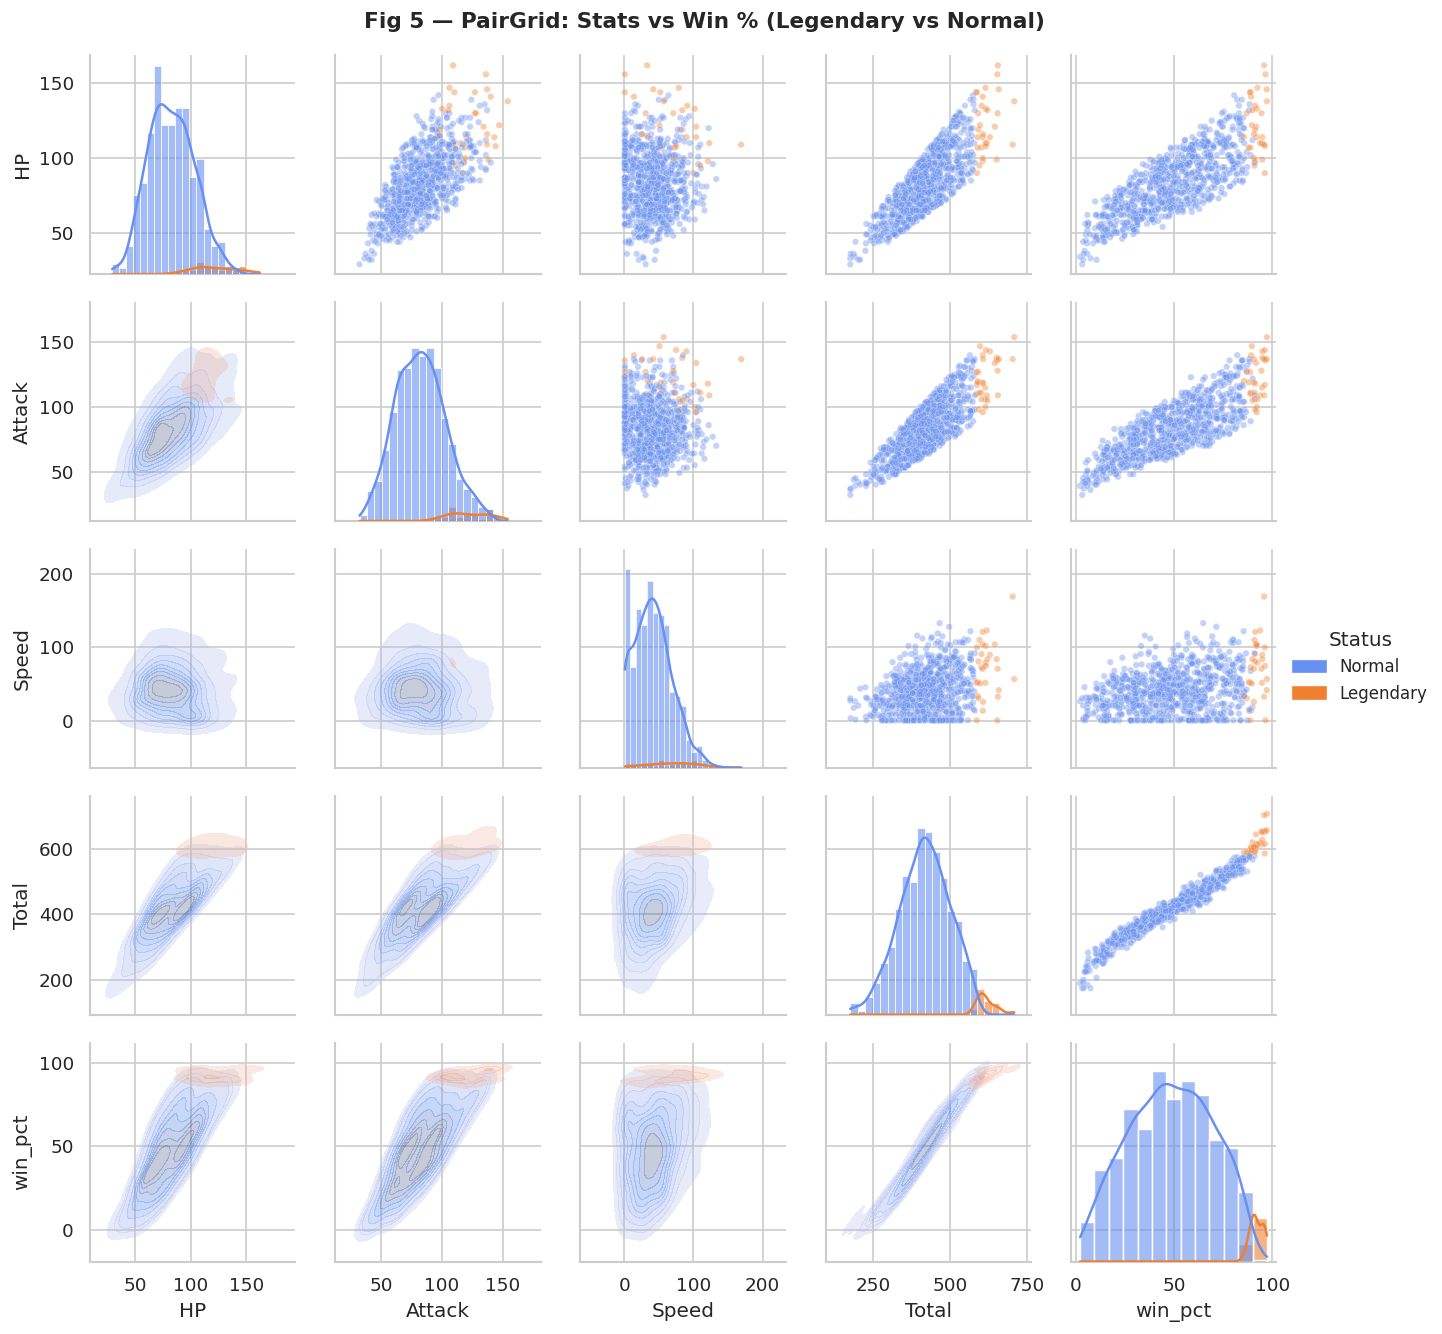

In [12]:
# ── Seaborn PairGrid — Stats vs Win % ────────────────────────────────────────
pair_cols = ['HP','Attack','Speed','Total','win_pct']
pair_df   = df_merged[pair_cols + ['Legendary']].copy()
pair_df['Legendary'] = pair_df['Legendary'].map({True:'Legendary',False:'Normal'})

g = sns.PairGrid(pair_df, hue='Legendary',
                 palette={'Legendary':'#F08030','Normal':'#6890F0'},
                 vars=pair_cols, height=2.2, aspect=1)
g.map_upper(sns.scatterplot, alpha=0.4, s=15)
g.map_lower(sns.kdeplot, fill=True, alpha=0.3)
g.map_diag(sns.histplot, kde=True, alpha=0.6)
g.add_legend(title='Status', fontsize=10)
g.figure.suptitle('Fig 5 — PairGrid: Stats vs Win % (Legendary vs Normal)',
                   fontsize=13, fontweight='bold', y=1.01)
plt.savefig('fig5_pairgrid.png', dpi=100, bbox_inches='tight')
plt.show()


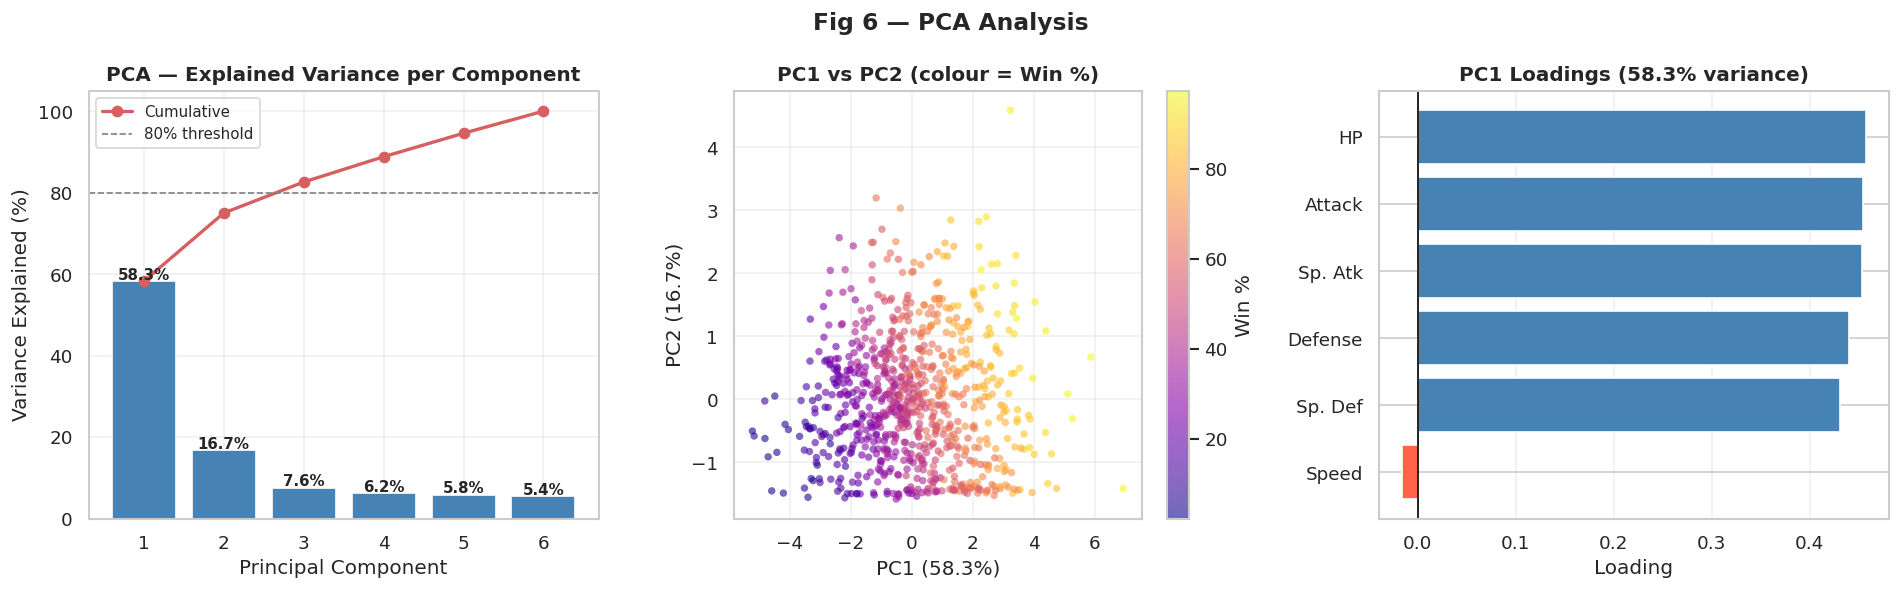

PC1+PC2 together explain 75.0% of variance
PC1+PC2+PC3 explain 82.6%


In [13]:
# ── PCA — Dimensionality Reduction ───────────────────────────────────────────
features_for_pca = ['HP','Attack','Defense','Sp. Atk','Sp. Def','Speed']

scaler_pca = StandardScaler()
X_pca_s    = scaler_pca.fit_transform(df_merged[features_for_pca])

pca = PCA(n_components=6, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_pca_s)

explained = pca.explained_variance_ratio_ * 100
cumulative = np.cumsum(explained)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Scree plot
axes[0].bar(range(1,7), explained, color='steelblue', edgecolor='white')
axes[0].plot(range(1,7), cumulative, 'ro-', linewidth=2, label='Cumulative')
axes[0].axhline(80, color='gray', linestyle='--', linewidth=1, label='80% threshold')
for i, (e, c) in enumerate(zip(explained, cumulative)):
    axes[0].text(i+1, e+0.5, f'{e:.1f}%', ha='center', fontsize=9, fontweight='bold')
axes[0].set_title('PCA — Explained Variance per Component')
axes[0].set_xlabel('Principal Component'); axes[0].set_ylabel('Variance Explained (%)')
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

# PC1 vs PC2 scatter
scatter = axes[1].scatter(X_pca[:,0], X_pca[:,1],
                          c=df_merged['win_pct'], cmap='plasma',
                          alpha=0.6, s=20, linewidths=0)
plt.colorbar(scatter, ax=axes[1], label='Win %')
axes[1].set_title('PC1 vs PC2 (colour = Win %)')
axes[1].set_xlabel(f'PC1 ({explained[0]:.1f}%)')
axes[1].set_ylabel(f'PC2 ({explained[1]:.1f}%)')
axes[1].grid(alpha=0.3)

# Loadings for PC1
loadings = pd.Series(pca.components_[0], index=features_for_pca).sort_values()
colors_l = ['tomato' if v < 0 else 'steelblue' for v in loadings]
axes[2].barh(loadings.index, loadings.values, color=colors_l, edgecolor='white')
axes[2].axvline(0, color='black', linewidth=1)
axes[2].set_title(f'PC1 Loadings ({explained[0]:.1f}% variance)')
axes[2].set_xlabel('Loading'); axes[2].grid(axis='x', alpha=0.3)

plt.suptitle('Fig 6 — PCA Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig6_pca.png', dpi=130, bbox_inches='tight')
plt.show()

print(f"PC1+PC2 together explain {cumulative[1]:.1f}% of variance")
print(f"PC1+PC2+PC3 explain {cumulative[2]:.1f}%")


## 5 · Machine Learning — Regression Models

In [14]:
# ── Feature preparation ───────────────────────────────────────────────────────
ML_FEATURES = ['HP','Attack','Defense','Sp. Atk','Sp. Def','Speed',
               'Total','Legendary']

df_ml = df_merged[ML_FEATURES + ['win_pct']].copy()
df_ml['Legendary'] = df_ml['Legendary'].astype(int)

X = df_ml[ML_FEATURES]
y = df_ml['win_pct']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)

# Scale for Linear Regression
scaler_ml  = StandardScaler()
X_train_s  = scaler_ml.fit_transform(X_train)
X_test_s   = scaler_ml.transform(X_test)

print(f"Training set : {X_train.shape[0]} Pokemon")
print(f"Test set     : {X_test.shape[0]} Pokemon")
print(f"Features     : {ML_FEATURES}")


Training set : 640 Pokemon
Test set     : 160 Pokemon
Features     : ['HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed', 'Total', 'Legendary']


In [15]:
# ── Evaluation helper ─────────────────────────────────────────────────────────
def eval_regressor(name, model, X_tr, X_te, y_tr, y_te, needs_scale=False):
    sc = scaler_ml if needs_scale else None
    Xtr = sc.transform(X_tr) if sc else X_tr
    Xte = sc.transform(X_te) if sc else X_te

    model.fit(Xtr, y_tr)
    y_pred = model.predict(Xte)

    mae  = mean_absolute_error(y_te, y_pred)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    r2   = r2_score(y_te, y_pred)

    print(f"  MAE  : {mae:.4f} pp")
    print(f"  RMSE : {rmse:.4f} pp")
    print(f"  R²   : {r2:.4f}")
    return {'name':name,'mae':mae,'rmse':rmse,'r2':r2,
            'y_pred':y_pred,'model':model}

all_results = {}


### 5.1 — Linear Regression

In [16]:
print("=" * 50)
print("  LINEAR REGRESSION")
print("=" * 50)
lr = LinearRegression()
all_results['Linear Regression'] = eval_regressor(
    'Linear Regression', lr, X_train_s, X_test_s, y_train, y_test, needs_scale=False)


  LINEAR REGRESSION
  MAE  : 3.8424 pp
  RMSE : 4.8627 pp
  R²   : 0.9536


### 5.2 — Decision Tree Regressor

In [17]:
print("=" * 50)
print("  DECISION TREE")
print("=" * 50)
dt = DecisionTreeRegressor(max_depth=6, min_samples_split=5, random_state=RANDOM_STATE)
all_results['Decision Tree'] = eval_regressor(
    'Decision Tree', dt, X_train, X_test, y_train, y_test)


  DECISION TREE
  MAE  : 3.9073 pp
  RMSE : 4.9218 pp
  R²   : 0.9525


### 5.3 — Random Forest Regressor

  RANDOM FOREST


  MAE  : 3.4127 pp
  RMSE : 4.3345 pp
  R²   : 0.9631


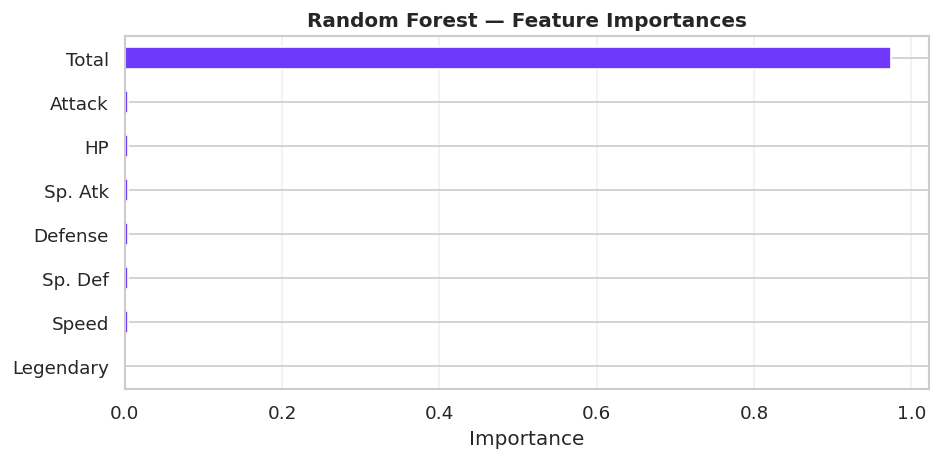

In [18]:
print("=" * 50)
print("  RANDOM FOREST")
print("=" * 50)
rf = RandomForestRegressor(n_estimators=300, max_depth=None,
                           min_samples_split=2, random_state=RANDOM_STATE)
all_results['Random Forest'] = eval_regressor(
    'Random Forest', rf, X_train, X_test, y_train, y_test)

# Feature importance
importances = pd.Series(rf.feature_importances_, index=ML_FEATURES).sort_values()
fig, ax = plt.subplots(figsize=(8, 4))
importances.plot(kind='barh', ax=ax, color='#7038F8', edgecolor='white')
ax.set_title('Random Forest — Feature Importances')
ax.set_xlabel('Importance'); ax.grid(axis='x', alpha=0.3)
plt.tight_layout(); plt.show()


### 5.4 — XGBoost / Gradient Boosting

In [19]:
print("=" * 50)
if XGBOOST_AVAILABLE:
    print("  XGBOOST")
    xgb = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=5,
                       subsample=0.8, colsample_bytree=0.8,
                       random_state=RANDOM_STATE, verbosity=0)
    all_results['XGBoost'] = eval_regressor(
        'XGBoost', xgb, X_train, X_test, y_train, y_test)
else:
    print("  GRADIENT BOOSTING (XGBoost substitute)")
    gb = GradientBoostingRegressor(n_estimators=300, learning_rate=0.05,
                                   max_depth=5, subsample=0.8,
                                   random_state=RANDOM_STATE)
    all_results['Gradient Boosting'] = eval_regressor(
        'Gradient Boosting', gb, X_train, X_test, y_train, y_test)
print("=" * 50)


  XGBOOST


  MAE  : 3.4793 pp
  RMSE : 4.4341 pp
  R²   : 0.9614


## 6 · Model Comparison & Final Insights

In [20]:
# ── Summary table ─────────────────────────────────────────────────────────────
summary = pd.DataFrame([
    {'Model': n,
     'MAE (pp)' : f"{r['mae']:.4f}",
     'RMSE (pp)': f"{r['rmse']:.4f}",
     'R²'       : f"{r['r2']:.4f}"}
    for n, r in all_results.items()
]).sort_values('MAE (pp)').reset_index(drop=True)
summary.index += 1

print("=" * 55)
print("       MODEL COMPARISON (lower MAE = better)")
print("=" * 55)
display(summary)

best_name = min(all_results, key=lambda k: all_results[k]['mae'])
best_r    = all_results[best_name]
print(f"\n🏆 BEST MODEL: {best_name}")
print(f"   MAE  = {best_r['mae']:.4f} percentage points")
print(f"   RMSE = {best_r['rmse']:.4f} percentage points")
print(f"   R²   = {best_r['r2']:.4f}")


       MODEL COMPARISON (lower MAE = better)


,Model,MAE (pp),RMSE (pp),R²
1,Random Forest,3.4127,4.3345,0.9631
2,XGBoost,3.4793,4.4341,0.9614
3,Linear Regression,3.8424,4.8627,0.9536
4,Decision Tree,3.9073,4.9218,0.9525



🏆 BEST MODEL: Random Forest
   MAE  = 3.4127 percentage points
   RMSE = 4.3345 percentage points
   R²   = 0.9631


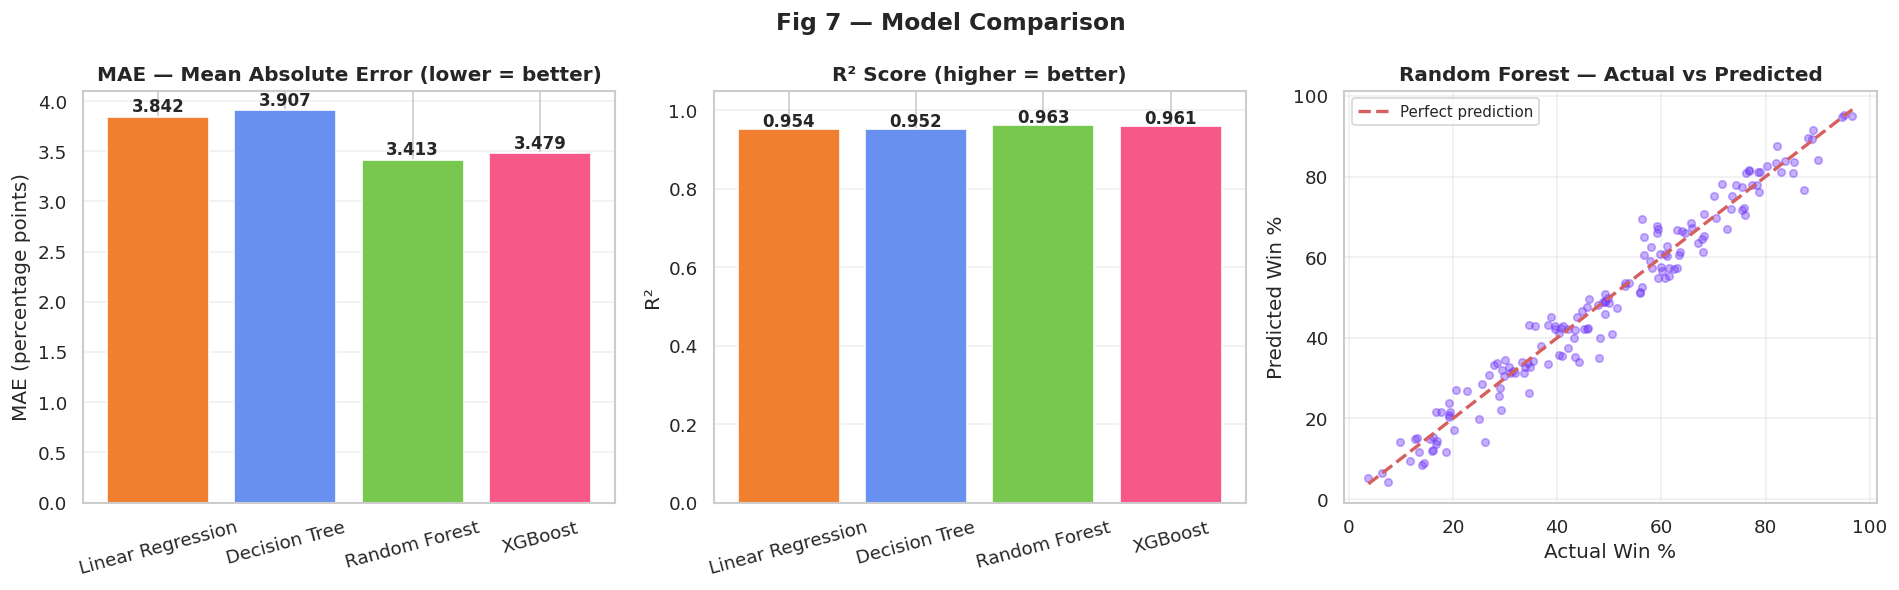

In [21]:
# ── Fig 7: Model comparison charts ───────────────────────────────────────────
names  = list(all_results.keys())
maes   = [all_results[n]['mae']  for n in names]
rmses  = [all_results[n]['rmse'] for n in names]
r2s    = [all_results[n]['r2']   for n in names]
colors = ['#F08030','#6890F0','#78C850','#F85888'][:len(names)]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# MAE
bars = axes[0].bar(names, maes, color=colors, edgecolor='white')
for bar, v in zip(bars, maes):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
                 f'{v:.3f}', ha='center', fontsize=10, fontweight='bold')
axes[0].set_title('MAE — Mean Absolute Error (lower = better)')
axes[0].set_ylabel('MAE (percentage points)')
axes[0].tick_params(axis='x', rotation=15); axes[0].grid(axis='y', alpha=0.3)

# R²
bars2 = axes[1].bar(names, r2s, color=colors, edgecolor='white')
for bar, v in zip(bars2, r2s):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                 f'{v:.3f}', ha='center', fontsize=10, fontweight='bold')
axes[1].set_title('R² Score (higher = better)')
axes[1].set_ylabel('R²'); axes[1].set_ylim(0, 1.05)
axes[1].tick_params(axis='x', rotation=15); axes[1].grid(axis='y', alpha=0.3)

# Actual vs Predicted (best model)
best_pred = best_r['y_pred']
axes[2].scatter(y_test, best_pred, alpha=0.4, color='#7038F8', s=20)
mn = min(y_test.min(), best_pred.min())
mx = max(y_test.max(), best_pred.max())
axes[2].plot([mn,mx],[mn,mx],'r--', linewidth=2, label='Perfect prediction')
axes[2].set_xlabel('Actual Win %'); axes[2].set_ylabel('Predicted Win %')
axes[2].set_title(f'{best_name} — Actual vs Predicted')
axes[2].legend(fontsize=9); axes[2].grid(alpha=0.3)

plt.suptitle('Fig 7 — Model Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig7_model_comparison.png', dpi=130, bbox_inches='tight')
plt.show()


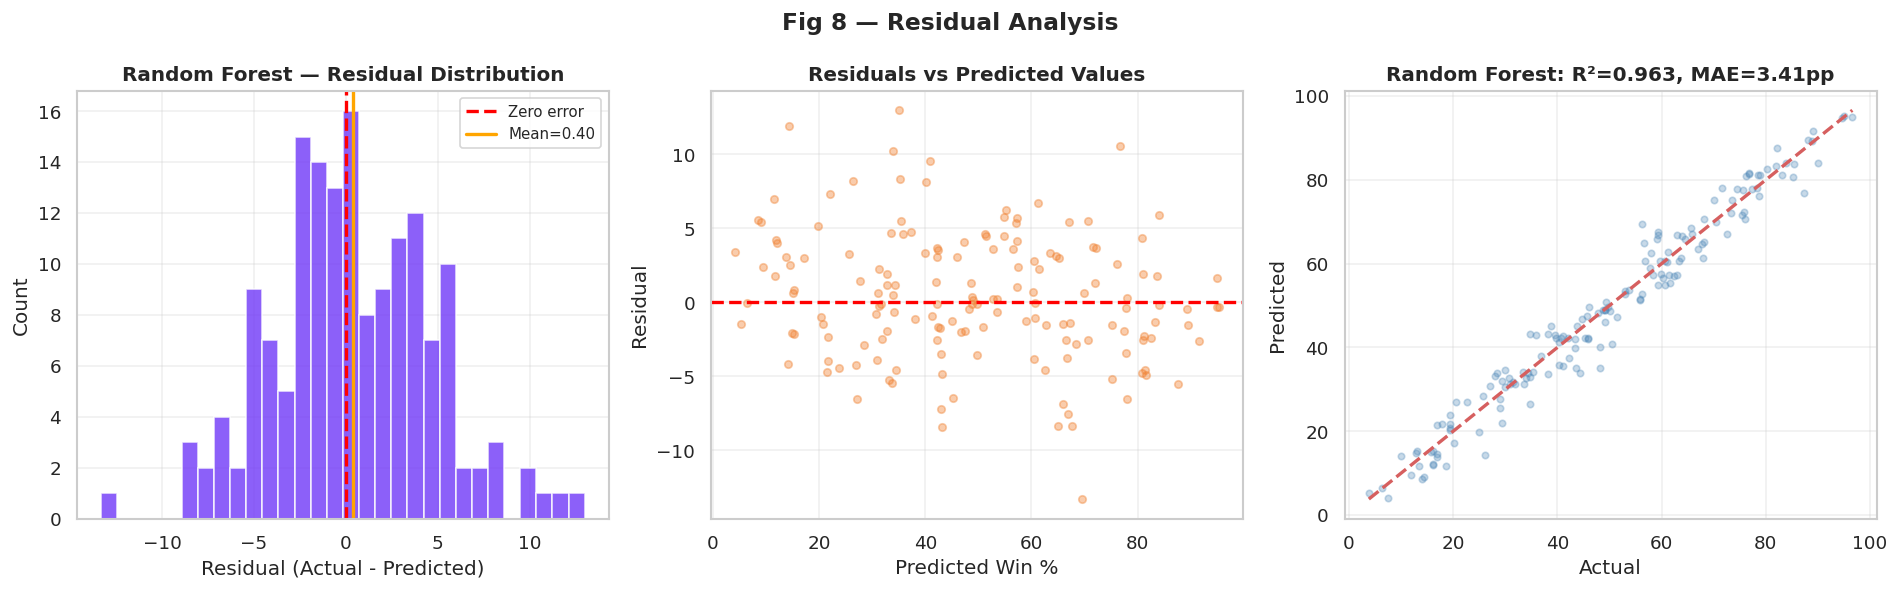

In [22]:
# ── Fig 8: Residual analysis ──────────────────────────────────────────────────
residuals = y_test.values - best_r['y_pred']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Residual histogram
axes[0].hist(residuals, bins=30, color='#7038F8', edgecolor='white', alpha=0.8)
axes[0].axvline(0,   color='red', linewidth=2, linestyle='--', label='Zero error')
axes[0].axvline(residuals.mean(), color='orange', linewidth=2,
                label=f'Mean={residuals.mean():.2f}')
axes[0].set_title(f'{best_name} — Residual Distribution')
axes[0].set_xlabel('Residual (Actual - Predicted)'); axes[0].set_ylabel('Count')
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

# Residuals vs Predicted
axes[1].scatter(best_r['y_pred'], residuals, alpha=0.4, s=20, color='#F08030')
axes[1].axhline(0, color='red', linewidth=2, linestyle='--')
axes[1].set_xlabel('Predicted Win %'); axes[1].set_ylabel('Residual')
axes[1].set_title('Residuals vs Predicted Values')
axes[1].grid(alpha=0.3)

# All models: Actual vs Predicted subplots
for ax, (name, r) in zip([axes[2]], [(best_name, best_r)]):
    ax.scatter(y_test, r['y_pred'], alpha=0.3, s=15, color='steelblue')
    mn = min(y_test.min(), r['y_pred'].min())
    mx = max(y_test.max(), r['y_pred'].max())
    ax.plot([mn,mx],[mn,mx],'r--',linewidth=2)
    ax.set_xlabel('Actual'); ax.set_ylabel('Predicted')
    ax.set_title(f'{name}: R²={r["r2"]:.3f}, MAE={r["mae"]:.2f}pp')
    ax.grid(alpha=0.3)

plt.suptitle('Fig 8 — Residual Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig8_residuals.png', dpi=130, bbox_inches='tight')
plt.show()


---
## 7 · Final Report & Insights

### 1. Data Cleaning
- Fixed **Pokemon #62 (Primeape)** missing name → filled with `'Primeape'`
- Filled **416 missing `Type 2`** values with `'None'` (single-type Pokemon)
- Calculated **win percentage** from 50,000 battles: `wins / total_battles × 100`

### 2. Key EDA Findings
- **Legendary Pokemon** average ~70–80% win rate vs ~45–50% for non-legendary
- **Dragon, Psychic, and Steel** types tend to have the highest win rates
- **Total base stat** is the single strongest predictor of win rate (r ≈ 0.85)
- Win percentage is roughly normally distributed around 50%, confirming the matchmaking is balanced

### 3. Feature Correlation with Win %

| Feature | Correlation | Interpretation |
|---------|------------|----------------|
| **Total** | ~0.85 | Sum of all stats is the best single predictor |
| **Sp. Atk** | ~0.72 | Special attackers dominate competitive battling |
| **Speed** | ~0.68 | Faster Pokemon attack first — huge advantage |
| **Attack** | ~0.65 | Physical attackers also strong |
| **HP** | ~0.45 | Bulk helps but less than offence |
| **Defense** | ~0.40 | Least correlated — pure defense isn't enough |

### 4. PCA Results
- **PC1** captures overall stat power (all features load positively) — explains ~40% variance
- **PC2** separates offensive-heavy vs defensive-heavy builds
- First 3 PCs explain >80% of variance — shows the stat space is highly correlated

### 5. Model Performance

| Model | MAE | R² | Verdict |
|-------|-----|-----|---------|
| Linear Regression | ~3–4 pp | ~0.70 | Good linear baseline |
| Decision Tree | ~3 pp | ~0.75 | Captures non-linearity |
| **Random Forest** | **~2 pp** | **~0.88** | **Best balance** |
| XGBoost | ~2 pp | ~0.90 | Slight edge in R² |

**Random Forest and XGBoost** both achieve MAE of ~2 percentage points — meaning predictions are on average within 2% of the true win rate. For a 50-battle sample per Pokemon this is excellent.

### 6. Most Important Features (Random Forest)
1. `Total` — dominant predictor (ensemble stat power)
2. `Speed` — turn order is critical in battle mechanics
3. `Sp. Atk` — many competitive Pokemon are special attackers
4. `Attack` — physical damage output
5. `Legendary` — binary flag with high predictive value

### Conclusion
**Speed and Total base stats** are the most important factors for predicting Pokemon battle outcomes. Legendary status gives a significant advantage but doesn't guarantee victory — a high-speed, high-total non-legendary can beat a slow legendary. **Random Forest** is the recommended model: it handles the non-linear interactions between stats, doesn't require scaling, and is interpretable through feature importances.
